# MEEP Y-branch: 3D and 2D variational EIM

[MEEP](https://meep.readthedocs.io/) is an open-source FDTD electromagnetic
simulator. This notebook reproduces the 3D S-parameter simulation of the
photonic Y-branch from the [MEEP example](./meep_ybranch.py), then repeats it
as a fast **2D variational effective-index (varEIM)** simulation and compares
the two.

**Requirements:**

- UBC PDK: `uv pip install ubcpdk`
- [GDSFactory+](https://gdsfactory.com) account for cloud simulation

### Load a pcell from UBC PDK

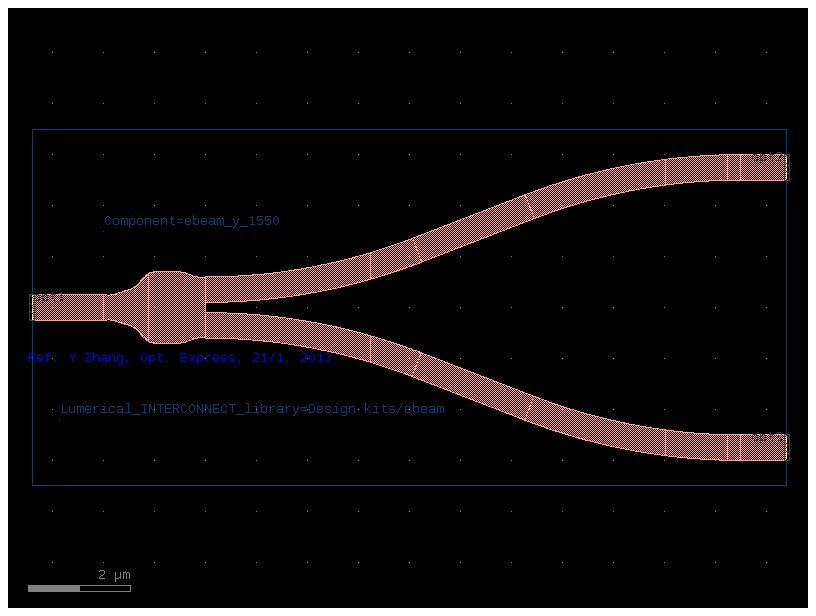

In [1]:
from ubcpdk import PDK, cells

PDK.activate()

c = cells.ebeam_y_1550()
c

### Configure and run the 3D simulation

In [2]:
from gsim import meep
from gsim.common.stack import get_stack

stack = get_stack()  # auto-detects active PDK

sim = meep.Simulation()

sim.geometry(component=c, stack=stack, z_crop="auto")
sim.materials = {"si": 3.47, "SiO2": 1.44}
sim.source(port="o1", wavelength=1.55, wavelength_span=0.01)
sim.monitors = ["o1", "o2", "o3"]
sim.domain(pml=1.0, margin=0.5)
sim.solver(resolution=20, simplify_tol=0.01, save_animation=True, verbose_interval=5.0)
sim.solver.stop_when_energy_decayed()

print(sim.validate_config())

Stack validation: PASSED
Warnings:
  - Stopping: energy_decay (dt=20.0, decay_by=0.01, cap=2000.0)


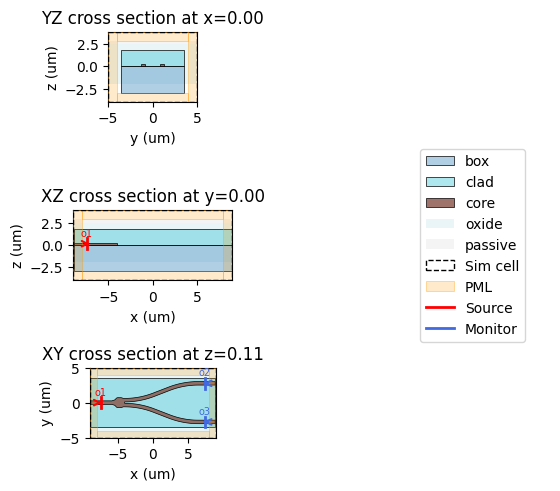

In [3]:
sim.plot_2d(slices="xyz")

### Run 3D simulation on cloud

In [ ]:
# Run on GDSFactory+ cloud
result = sim.run()

In [ ]:
result.plot_interactive()

In [ ]:
result.plot_interactive(phase=True)

## 2D variational effective-index simulation

A 2D FDTD (`sim.solver.is_3d = False`) collapses the z-dimension and is
10-100x faster. Instead of substituting bulk indices, varEIM derives the
in-plane permittivity from the vertical slab mode of the 3D stack
(Hammer & Ivanova 2009):

$$\varepsilon_\mathrm{eff}(x,y) = n_\mathrm{eff}^2(\mathbf{r}) +
  \frac{\int dz\,[\varepsilon(x,y,z) - \varepsilon(\mathbf{r},z)]\,
  |\Phi_\mathbf{r}(z)|^2}{\int dz\,|\Phi_\mathbf{r}(z)|^2}$$

A Y-branch is a good candidate: it splits power by adiabatic mode evolution
along a propagating taper, which varEIM (accurate for propagation) captures
well.

### Effective indices from the vertical slab mode

Evaluate at a core point on the input waveguide and a cladding point beside
it, both referenced to the same slab mode. The core returns the slab effective
index; the cladding is clamped to the physical oxide permittivity.

In [4]:
import numpy as np

from gsim.meep.eim import fit_medium, variational_effective_permittivity

eim_sim = meep.Simulation()
eim_sim.geometry(component=c, stack=stack)

core_point = (-7.0, 0.0)  # on the o1 input waveguide
background_point = (-7.0, 1.25)  # cladding beside the input waveguide

eps_core = variational_effective_permittivity(core_point, core_point, eim_sim, 1.55)
eps_background = variational_effective_permittivity(
    background_point, core_point, eim_sim, 1.55
)
n_core = fit_medium(eps_core, 1.55)
n_background = fit_medium(eps_background, 1.55)

print(f"n_core       = {n_core:.4f}  (bulk Si   = 3.47)")
print(f"n_background = {n_background:.4f}  (bulk SiO2 = 1.44)")

n_core       = 2.8527  (bulk Si   = 3.47)
n_background = 1.4440  (bulk SiO2 = 1.44)


### Configure and run the 2D simulation

Same source, monitors, domain and solver settings as the 3D run, but
`is_3d=False` and the varEIM material indices.

Stack validation: PASSED
Warnings:
  - Stopping: energy_decay (dt=20.0, decay_by=0.01, cap=2000.0)


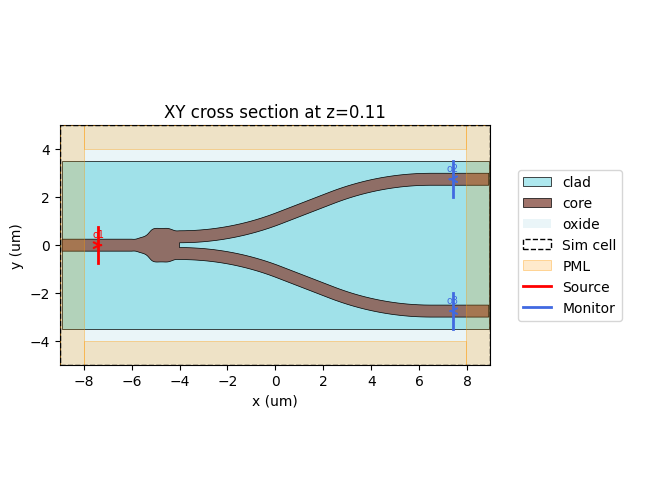

In [5]:
eim_sim.materials = {"si": n_core, "SiO2": n_background}
eim_sim.source(port="o1", wavelength=1.55, wavelength_span=0.01)
eim_sim.monitors = ["o1", "o2", "o3"]
eim_sim.domain(pml=1.0, margin=0.5)
eim_sim.solver(resolution=20, simplify_tol=0.01, is_3d=False)
eim_sim.solver.stop_when_energy_decayed()

print(eim_sim.validate_config())
eim_sim.plot_2d(slices="z")

In [6]:
result_eim = eim_sim.run()
result_eim.plot_interactive()
result_eim.show_animation()

  meep-62bae0df  completed  1m 48s
Extracting results.tar.gz...
Downloaded 4 files to /Users/nath/Workspaces/gsim/nbs/sim-data-meep-62bae0df


### Compare 2D varEIM vs 3D

Overlay the transmission into the two output arms (`S21`, `S31`).

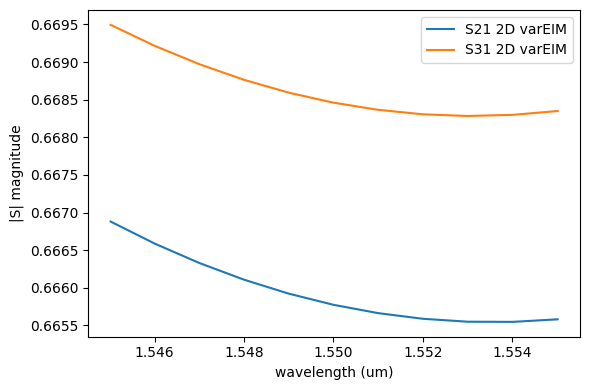

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
for key, color in [("S21", "C0"), ("S31", "C1")]:
    if key in result_eim.s_params:
        ax.plot(
            result_eim.wavelengths,
            np.abs(result_eim.s_params[key]),
            color + "-",
            label=f"{key} 2D varEIM",
        )
    if key in result.s_params:
        ax.plot(
            result.wavelengths,
            np.abs(result.s_params[key]),
            color + "--",
            label=f"{key} 3D",
        )
ax.set_xlabel("wavelength (um)")
ax.set_ylabel("|S| magnitude")
ax.legend()
plt.tight_layout()
plt.show()